# Dự án Phân tích và Dự báo Khách hàng Rời bỏ (Telco Customer Churn)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Import lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

## 1. Tải dữ liệu và Kiểm tra tổng quan

In [ ]:
#Load data to Data Frame
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/HHTQD/Telco_customer_churn.xlsx"
df = pd.read_excel(DATA_PATH)
print(f"5 dòng đầu tiên của df")
df.head()

5 dòng đầu tiên của df


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
print(f"Thông tin tổng quan các thuộc tính")
df.info()

Thông tin tổng quan các thuộc tính
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   ob

## 2. Tiền xử lý dữ liệu (Data Preprocessing)
Trong phần này, chúng ta sẽ xử lý kiểu dữ liệu, các giá trị thiếu và loại bỏ các cột không cần thiết cho mô hình.

Vì cột total charges đang là object type nên ta chuyển về numerical data

In [ ]:
#Preprocessing
Col_to_num = ['Total Charges']

for col in Col_to_num:
  df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
#Số lượng thuộc tính của các kiểu dữ liệu
print(f"""Number of:

float: {len(df.select_dtypes('float').columns)}
int: {len(df.select_dtypes('int').columns)}
object: {len(df.select_dtypes('object').columns)}
""")

Number of:

float: 4
int: 6
object: 23



In [ ]:
#Kiểm tra các cột bị thiếu dữ liệu
data_na = (df.isnull().sum() / len(df))
data_na = data_na.drop(data_na[data_na == 0].index).sort_values(ascending=False)
missing_data = pd.DataFrame({'mean of nulls' :data_na, "number of nulls" : df[data_na.index].isna().sum()})
print(f"Các cột bị thiếu dữ liệu")
missing_data

Các cột bị thiếu dữ liệu


,mean of nulls,number of nulls
Churn Reason,0.734630,5174
Total Charges,0.001562,11


In [ ]:
#Xử lý cột Churn Reason
df['Churn Label'].value_counts(normalize=True)

,proportion
Churn Label,
No,0.73463
Yes,0.26537


Có khoảng 73% khách hàng có Churn Label = No  nên họ không có Churn Reason. Vì vậy đối với cột Churn Reason chúng ta sẽ loại bỏ nó vì có hơn một nữa dữ liệu trong cột bị thiếu.

In [ ]:
df[df['Total Charges'].isna()]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,...,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,...,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,...,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,...,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,...,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,...,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,...,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,...,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,...,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,NaN


Chúng ta có số tháng khách hàng sử dụng dịch vụ (Tenure Months) và chi phí hàng tháng (Monthly Charges). Vì vậy, chúng ta có thể thay thế các giá trị bị thiếu bằng cách tính Monthly Charges × Tenure Months.

In [ ]:
df['Total Charges'].fillna(df['Monthly Charges'] * df['Tenure Months'], inplace=True)

## 3. Phân tích Khám phá Dữ liệu (EDA)
Phân tích tỷ lệ rời bỏ dựa trên các đặc điểm nhân khẩu học, loại hợp đồng và hành vi khách hàng.

In [ ]:
#Kiểm tra số lượng giá trị đặc trưng của các cột
df.nunique()

,0
CustomerID,7043
Count,1
Country,1
State,1
City,1129
Zip Code,1652
Lat Long,1652
Latitude,1652
Longitude,1651
Gender,2


Các cột có cùng một dữ liệu cho mọi dòng (low cardinality):

Cột Count |
Cột Country |
Cột State

Các cột có quá nhiều giá trị duy nhất (high cardinality):

Cột CustomerID |
Cột Zip Code |

In [ ]:
df.groupby(['Country','State']).size()

,,0
Country,State,
United States,California,7043


Toàn bộ lượng khách hàng của tệp này đều đến từ bang Cali của Mỹ

In [ ]:
Churn_Label_counts= df['Churn Label'].value_counts()
fig2 = px.pie(names= Churn_Label_counts.keys(), values= Churn_Label_counts.values, title='Phân phối của cột Churn Label')
fig2.show()

Có 26.5% lượng khách hàng đã ngừng sử dụng dịch vụ. Chúng ta phải xác định được nhóm khách hàng nào có khả năng rời đi cao và hành động có thể thực hiện để giữ chân họ.

In [ ]:
values= df['Churn Reason'].value_counts(ascending=False).values
keys= df['Churn Reason'].value_counts(ascending=False).keys()

fig = px.bar(x=keys, y=values, text = values) #, color = values

fig.update_layout(
    yaxis_title="Churn Reason",
    xaxis_title="Count"
)
fig.show()

Biểu đồ cho thấy lý do khách hàng rời đi có thể được chia thành 2 nhóm chính \
Bên trong: Chất lượng dịch vụ, Chất lượng sản phẩm, Giá cả,...\
Bên ngoài: Đối thủ cạnh tranh, Độ ổn định mạng,...

In [ ]:
#Đếm số lượng thành phố
num_city = df['City'].nunique()
print(f"Có {num_city} thành phố")

Có 1129 thành phố


In [ ]:
# Gom nhóm thành phố (City) và Nhãn rời bỏ (Churn label)
grouped = df.groupby(['City', 'Churn Label'])['CustomerID'].count()
total_counts = grouped.groupby('City').transform('sum')
churn_rate = round(grouped / total_counts, 2)
City_ChurnLabel = pd.DataFrame({'churn_rate': churn_rate}).reset_index()

# Tạo df chứa tổng số khách hàng theo từng thành phố
city_counts = df.groupby('City')['CustomerID'].count().reset_index()
city_counts.rename(columns={'CustomerID': 'count'}, inplace=True)

# Kết hợp City, Churn Label, city_counts
City_ChurnLabel = City_ChurnLabel.merge(city_counts, on='City')

# Loại bỏ các khách hàng có nhãn Churn Label = No và sắp xếp theo count
City_ChurnLabel = City_ChurnLabel[City_ChurnLabel['Churn Label'] == 'Yes']
City_ChurnLabel = City_ChurnLabel.sort_values(by='count', ascending=False)
City_ChurnLabel.drop(columns='Churn Label', inplace=True)

City_ChurnLabel.head()

,City,churn_rate,count
976,Los Angeles,0.30,305
1502,San Diego,0.33,150
1518,San Jose,0.26,112
1479,Sacramento,0.24,108
1508,San Francisco,0.30,104


In [ ]:
fig = px.bar(City_ChurnLabel.head(20), x='City', y= 'count', title='Số lượng khách hàng của từng thành phố xếp theo số lượng', text ='count')
fig.update_layout(
    xaxis_title="Thành phố",
    yaxis_title="Số lượng khách hàng"
)
fig.show()

Qua biểu đồ ta có thể thấy LA là nơi tập trung lượng khách hàng lớn nhất.

In [ ]:
fig = px.bar(City_ChurnLabel.sort_values(by='churn_rate', ascending=True).head(30),
             x='City', y= 'churn_rate', title='Những thành phố có khách hàng trung thành nhất', text ='churn_rate')#, color='churn_rate')
fig.update_layout(
    xaxis_title="Thành phố",
    yaxis_title="Tỷ lệ rời đi"
)
fig.show()

In [ ]:
fig = px.bar(City_ChurnLabel.sort_values(by='churn_rate', ascending=False).head(30),
             x='City', y= 'churn_rate', title='Những thành phố có tỷ lệ rời đi cao nhất', text ='churn_rate') #, color='churn_rate'
fig.update_layout(
    xaxis_title="Thành phố",
    yaxis_title="Tỷ lệ rời đi"
)
fig.show()

In [ ]:
fig = px.scatter(City_ChurnLabel, x="count",
                 y="churn_rate",
                 size = 'churn_rate', labels='City',
                 color = 'churn_rate')


fig.update_layout(
    xaxis_title="Số lượng khách hàng",
    yaxis_title="Tỷ lệ rời đi",
    title="Tương quan giữa quy mô thành phố và tỷ lệ rời bỏ",
    coloraxis_colorbar=dict(title="Tỷ lệ rời đi")
)

fig.show()

Qua biểu đồ phân tán ta có thể thấy những nơi có tỷ lệ khách hàng rời đi cao là những nơi có số lượng khách hàng nhỏ.

In [ ]:
fig = px.histogram(df, x="Tenure Months", color="Churn Label",
                   title="Phân bổ thời gian gắn bó theo trạng thái Rời bỏ")

fig.update_layout(
    xaxis_title="Số tháng gắn bó",
    yaxis_title="Số lượng khách hàng"
)
fig.show()

Số lượng khách hàng rời đi giảm mạnh sau 5 tháng đầu sử dụng dịch vụ.

In [ ]:
TenureMonths= df.groupby('Churn Label')['Tenure Months'].quantile([.50,.75,.90,.95]).reset_index()
TenureMonths['level_1']=TenureMonths['level_1'].astype(str)

fig = px.bar(TenureMonths, x='level_1', y= 'Tenure Months',
             color= 'Churn Label', barmode="group", text = 'Tenure Months' )

fig.update_xaxes(title="Quantiles")
fig.show()

Nửa số khách hàng rời dịch vụ đã rời đi chỉ sau 10 tháng đầu gắn bó.

In [ ]:
Contract_Label_counts= df['Contract'].value_counts()
fig1 = px.pie(names= Contract_Label_counts.keys(), values= Contract_Label_counts.values, title='Contract Distribution')
fig1.show()

Đa số khách hàng ký hợp đồng theo tháng

In [ ]:
# Group by 'Contract' and 'Churn Label' and count the occurrences
grouped = df.groupby(['Contract', 'Churn Label'])['CustomerID'].count()
total_counts = grouped.groupby('Contract').transform('sum')
normalized_count = round(grouped / total_counts,2)
Contract_ChurnLabel = pd.DataFrame({'normalized_count': normalized_count}).reset_index()

Contract_ChurnLabel

,Contract,Churn Label,normalized_count
0,Month-to-month,No,0.57
1,Month-to-month,Yes,0.43
2,One year,No,0.89
3,One year,Yes,0.11
4,Two year,No,0.97
5,Two year,Yes,0.03


In [ ]:
fig = px.bar(Contract_ChurnLabel, x='normalized_count', y='Contract', color='Churn Label',
             title='100% Stacked Bar Chart by Contract and Churn Label', text= 'normalized_count',
             labels={'normalized_count': 'Percentage'})

fig.update_layout(barmode='relative')

fig.show()

Câu này phản ánh một quy luật rất phổ biến trong kinh doanh dịch vụ (SaaS/Viễn thông). Bạn có thể dịch sang tiếng Việt một cách chuyên nghiệp như sau:

"Tỷ lệ rời bỏ cao nhất thuộc về nhóm hợp đồng theo từng tháng (Month-to-month) với mức 43%. Tỷ lệ này thấp hơn ở nhóm hợp đồng một năm (11%) và thấp nhất ở nhóm hợp đồng hai năm, chỉ ở mức 3%

In [ ]:
fig = px.pie(df.groupby(['Contract','Churn Label'])['CustomerID'].count().reset_index(),
             values='CustomerID',
            names='Contract',
            facet_col = 'Churn Label',
            title = 'Churn rate by contract type')

fig.show()

Trong số tất cả khách hàng rời bỏ dịch vụ, có tới 88,7% là những người sử dụng loại hợp đồng theo từng tháng (Month-to-month). Ngược lại, những người ký hợp đồng dài hạn hai năm chỉ chiếm một tỷ lệ rất nhỏ là 2,57% trong nhóm khách hàng rời đi.

In [ ]:
# Group by 'Contract' and 'Churn Label' and count the occurrences
grouped = df.groupby(['Gender', 'Churn Label'])['CustomerID'].count()
total_counts = grouped.groupby('Gender').transform('sum')
normalized_count = round(grouped / total_counts,2)
Gender_ChurnLabel = pd.DataFrame({'rate': normalized_count}).reset_index()

Gender_ChurnLabel

fig = px.bar(Gender_ChurnLabel, x='rate', y='Gender', color='Churn Label',
             title='100% Stacked Bar Chart by Contract and Churn Label', text= 'rate',
             labels={'rate': 'Percentage'})

fig.update_layout(barmode='relative')  # Make the bar chart 100% stacked

fig.show()

Không có sự khác biệt về tỷ lệ rời đi giữa 2 giới tính

In [ ]:
Payment_Method_counts= df['Payment Method'].value_counts()
fig = px.pie(names= Payment_Method_counts.keys(), values= Payment_Method_counts.values, title='Payment Method Distribution')
fig.show()

Phần lớn khách hàng sử dụng Electronic check làm phương thức thanh toán (33.6%)

In [ ]:
# Group by 'Contract' and 'Churn Label' and count the occurrences
grouped = df.groupby(['Payment Method', 'Churn Label'])['CustomerID'].count()
total_counts = grouped.groupby('Payment Method').transform('sum')
normalized_count = round(grouped / total_counts,2)
Payment_Method_ChurnLabel = pd.DataFrame({'rate': normalized_count}).reset_index()

fig = px.bar(Payment_Method_ChurnLabel, x='rate', y='Payment Method', color='Churn Label',
             title='100% Stacked Bar Chart by Payment Method and Churn Label', text= 'rate',
             labels={'rate': 'Percentage'})

fig.update_layout(barmode='relative')  # Make the bar chart 100% stacked

fig.show()

Kết quả phân tích cho thấy những khách hàng sử dụng phương thức thanh toán bằng Electronic check có tỷ lệ rời bỏ lên tới 45%. Trong khi đó, nhóm khách hàng thanh toán qua Credit card có tỷ lệ rời bỏ thấp nhất, chỉ khoảng 15%.

In [ ]:
corr_df = df.copy()

corr_df['Churn Label'].replace(to_replace='Yes', value=1, inplace=True)
corr_df['Churn Label'].replace(to_replace='No',  value=0, inplace=True)

df_dummies = pd.get_dummies(corr_df[['Churn Label','Phone Service','Multiple Lines','Internet Service','Online Security',
                                 'Online Backup','Device Protection','Tech Support','Streaming TV',
                                 'Streaming Movies']])
df_dummies.head()

,Churn Label,Phone Service_No,Phone Service_Yes,Multiple Lines_No,Multiple Lines_No phone service,Multiple Lines_Yes,Internet Service_DSL,Internet Service_Fiber optic,Internet Service_No,Online Security_No,...,Device Protection_Yes,Tech Support_No,Tech Support_No internet service,Tech Support_Yes,Streaming TV_No,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No,Streaming Movies_No internet service,Streaming Movies_Yes
0,1,False,True,True,False,False,True,False,False,False,...,False,True,False,False,True,False,False,True,False,False
1,1,False,True,True,False,False,False,True,False,True,...,False,True,False,False,True,False,False,True,False,False
2,1,False,True,False,False,True,False,True,False,True,...,True,True,False,False,False,False,True,False,False,True
3,1,False,True,False,False,True,False,True,False,True,...,True,False,False,True,False,False,True,False,False,True
4,1,False,True,False,False,True,False,True,False,True,...,True,True,False,False,False,False,True,False,False,True


In [ ]:
data = df.drop(['Country','State','Count','Zip Code','Churn Reason','City','Churn Score','Churn Value','CLTV','CustomerID','Lat Long',
                  'Latitude','Longitude'], axis = 1)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [ ]:
data['Churn Label'].replace(to_replace='Yes', value=1, inplace=True)
data['Churn Label'].replace(to_replace='No',  value=0, inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder
def encode_data(dataframe_series):
    if dataframe_series.dtype=='object':
        dataframe_series = LabelEncoder().fit_transform(dataframe_series)
    return dataframe_series


In [ ]:
data = data.apply(lambda x: encode_data(x))
data.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label
0,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
1,0,0,0,1,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
2,0,0,0,1,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,820.50,1
3,0,0,1,1,28,1,2,1,0,0,2,2,2,2,0,1,2,104.80,3046.05,1
4,1,0,0,1,49,1,2,1,0,2,2,0,2,2,0,1,0,103.70,5036.30,1


In [ ]:
fig = px.bar(data.corr()['Churn Label'].sort_values(ascending = False))
fig.show()

## 4. Xây dựng Mô hình Dự báo (Machine Learning)
Chúng ta sẽ sử dụng kỹ thuật SMOTE để xử lý mất cân bằng dữ liệu và huấn luyện mô hình XGBoost.

In [ ]:
data.groupby('Churn Label')['Churn Label'].count()

,Churn Label
Churn Label,
0,5174
1,1869


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
# over = SMOTE(sampling_strategy = 1)

# x = data.drop("Churn Label", axis = 1).values
# y = data['Churn Label'].values



In [ ]:
# x,y = over.fit_resample(x,y)

In [ ]:
from imblearn.pipeline import Pipeline
# from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, f1_score,recall_score, precision_score
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve, auc
from xgboost import XGBClassifier
# from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

x = data.drop("Churn Label", axis=1).values
y = data['Churn Label'].values

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state =2, test_size = 0.2)

over = SMOTE(sampling_strategy=1, random_state=42)
x_train_resampled, y_train_resampled = over.fit_resample(x_train, y_train)

In [ ]:
def model_XG(method, x_train, y_train, x_test, y_test):
    # Train the model
    method.fit(x_train, y_train)

    # Make predictions on test data and calculate confusion matrix
    predictions = method.predict(x_test)
    c_matrix = confusion_matrix(y_test, predictions)

    # Calculate label percentages and create label strings with counts and percentages
    percentages = (c_matrix / np.sum(c_matrix, axis=1)[:, np.newaxis]).round(2) * 100
    labels = [[f"{c_matrix[i, j]} ({percentages[i, j]:.2f}%)" for j in range(c_matrix.shape[1])] for i in range(c_matrix.shape[0])]
    labels = np.asarray(labels)

    # Plot confusion matrix with labeled counts and percentages
    sns.heatmap(c_matrix, annot=labels, fmt='', cmap='Blues')

    # Evaluate model performance and print results
    print("ROC AUC: ", '{:.2%}'.format(roc_auc_score(y_test, predictions)))
    print("Model accuracy: ", '{:.2%}'.format(accuracy_score(y_test, predictions)))
    print(classification_report(y_test, predictions))




# def model_LR(x_train, y_train, x_test, y_test):
#     scaler = StandardScaler()
#     x_train_scaled = scaler.fit_transform(x_train)
#     x_test_scaled = scaler.transform(x_test)

#     lr_model = LogisticRegression(max_iter=1000, random_state=2)
#     lr_model.fit(x_train_scaled, y_train)

#     predictions = lr_model.predict(x_test_scaled)
#     c_matrix = confusion_matrix(y_test, predictions)

#     percentages = (c_matrix / np.sum(c_matrix, axis=1)[:, np.newaxis]).round(2) * 100
#     labels = [[f"{c_matrix[i, j]} ({percentages[i, j]:.2f}%)" for j in range(c_matrix.shape[1])] for i in range(c_matrix.shape[0])]
#     labels = np.asarray(labels)

#     sns.heatmap(c_matrix, annot=labels, fmt='', cmap='Greens')
#     plt.show()

#     print("--- Hồi quy Logistic ---")
#     print("ROC AUC: ", '{:.2%}'.format(roc_auc_score(y_test, predictions)))
#     print("Model accuracy: ", '{:.2%}'.format(accuracy_score(y_test, predictions)))
#     print(classification_report(y_test, predictions))

#     return lr_model


def model_RF(x_train, y_train, x_test, y_test):
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=2)
    rf_model.fit(x_train, y_train)

    predictions = rf_model.predict(x_test)
    c_matrix = confusion_matrix(y_test, predictions)

    percentages = (c_matrix / np.sum(c_matrix, axis=1)[:, np.newaxis]).round(2) * 100
    labels = [[f"{c_matrix[i, j]} ({percentages[i, j]:.2f}%)" for j in range(c_matrix.shape[1])] for i in range(c_matrix.shape[0])]
    labels = np.asarray(labels)

    sns.heatmap(c_matrix, annot=labels, fmt='', cmap='Greens')
    plt.show()

    # 4. In các chỉ số đánh giá
    print("--- Random Forest Classifier ---")
    print("ROC AUC: ", '{:.2%}'.format(roc_auc_score(y_test, predictions)))
    print("Model accuracy: ", '{:.2%}'.format(accuracy_score(y_test, predictions)))
    print(classification_report(y_test, predictions))

    return rf_model

In [ ]:
xgb = XGBClassifier(learning_rate= 0.01,max_depth = 3,n_estimators = 1000)

ROC AUC:  71.93%
Model accuracy:  81.33%
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1028
           1       0.72      0.51      0.60       381

    accuracy                           0.81      1409
   macro avg       0.78      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



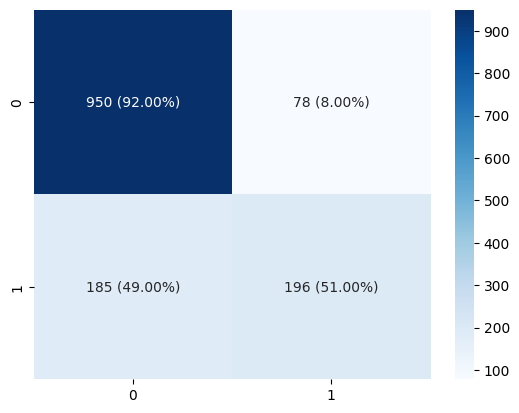

In [ ]:
model_XG(xgb,x_train,y_train,x_test,y_test)

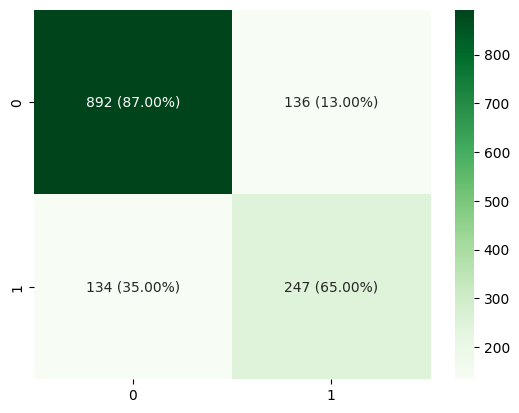

--- Random Forest Classifier ---
ROC AUC:  75.80%
Model accuracy:  80.84%
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1028
           1       0.64      0.65      0.65       381

    accuracy                           0.81      1409
   macro avg       0.76      0.76      0.76      1409
weighted avg       0.81      0.81      0.81      1409



In [ ]:
# lr_fitted = model_LR(x_train, y_train, x_test, y_test)
rf_fitted = model_RF(x_train_resampled, y_train_resampled, x_test, y_test)

## So sánh kết quả số liệu giữa XGBoost và Random Forest

Dưới đây là tổng hợp các chỉ số hiệu suất chính từ việc đánh giá hai mô hình:

| Chỉ số       | XGBoost      | Random Forest |
| :----------- | :----------- | :------------ |
| **ROC AUC**  | 71.93%       | 75.80%        |
| **Độ chính xác (Accuracy)** | 81.33%       | 80.84%        |
| **Churn (class 1) Precision** | 0.72       | 0.64        |
| **Churn (class 1) Recall**    | 0.51       | 0.65        |
| **Churn (class 1) F1-Score**  | 0.60       | 0.65        |

**Nhận xét:**

*   **ROC AUC**: Random Forest đạt giá trị ROC AUC cao hơn (75.80% so với 71.93%), cho thấy khả năng phân loại tổng thể tốt hơn trong việc phân biệt giữa khách hàng rời bỏ và không rời bỏ.
*   **Độ chính xác (Accuracy)**: Cả hai mô hình có độ chính xác tổng thể tương đương, với XGBoost nhỉnh hơn một chút (81.33% so với 80.84%).
*   **Precision (class 1)**: XGBoost có Precision cao hơn (0.72 so với 0.64), nghĩa là khi XGBoost dự đoán một khách hàng sẽ rời bỏ, khả năng dự đoán đó chính xác cao hơn.
*   **Recall (class 1)**: Random Forest có Recall cao hơn (0.65 so với 0.51), nghĩa là Random Forest có khả năng phát hiện được nhiều khách hàng sẽ rời bỏ hơn trong tổng số khách hàng thực sự rời bỏ.
*   **F1-Score (class 1)**: Random Forest đạt F1-Score cao hơn (0.65 so với 0.60), cho thấy sự cân bằng tốt hơn giữa Precision và Recall cho lớp khách hàng rời bỏ.

Việc lựa chọn mô hình cuối cùng sẽ phụ thuộc vào ưu tiên kinh doanh: nếu muốn giảm thiểu số lượng khách hàng bị dự đoán sai là rời bỏ (dẫn đến chi phí can thiệp không cần thiết), Precision của XGBoost sẽ hữu ích. Nếu muốn xác định càng nhiều khách hàng có nguy cơ rời bỏ càng tốt (để không bỏ lỡ cơ hội giữ chân họ), Recall của Random Forest sẽ được ưu tiên hơn.

## 5. Dự báo và Lập danh sách khách hàng có nguy cơ rời bỏ
Sử dụng mô hình đã huấn luyện để quét toàn bộ dữ liệu và lọc ra những khách hàng có xác suất rời bỏ cao nhất.

In [ ]:
# Lấy các đặc trưng (features) tương ứng với dữ liệu đã dùng để huấn luyện
X_full = data.drop("Churn Label", axis=1).values

# Dự báo xác suất rời bỏ (class 1)
churn_probabilities = xgb.predict_proba(X_full)[:, 1]

# Tạo DataFrame kết quả, bao gồm cả Risk_Level từ df_export
prediction_results = pd.DataFrame({
    'CustomerID': df['CustomerID'],
    'Churn_Probability': churn_probabilities,
    'Current_Status': df['Churn Label'],
    'Risk_Level': df_export['Risk_Level']
})

# Lọc ra những khách hàng CHƯA rời bỏ (Churn Label = No) nhưng có xác suất rời bỏ cao
# Giả sử ngưỡng (threshold) là 0.5
priority_list = prediction_results[prediction_results['Current_Status'] == 'No'].sort_values(by='Churn_Probability', ascending=False)

print("Top 10 khách hàng có nguy cơ rời bỏ cao nhất cần ưu tiên chăm sóc:")
display(priority_list.head(10))

Top 10 khách hàng có nguy cơ rời bỏ cao nhất cần ưu tiên chăm sóc:


,CustomerID,Churn_Probability,Current_Status,Risk_Level
5906,4912-PIGUY,0.887468,No,High Risk
5657,7577-SWIFR,0.881767,No,High Risk
2125,0021-IKXGC,0.871605,No,High Risk
2676,7439-DKZTW,0.867852,No,High Risk
4551,3878-AVSOQ,0.864595,No,High Risk
2215,1452-VOQCH,0.860577,No,High Risk
6353,9605-WGJVW,0.859748,No,High Risk
6213,1628-BIZYP,0.857204,No,High Risk
3662,9603-OAIHC,0.856692,No,High Risk
4341,2545-EBUPK,0.850744,No,High Risk


### Giải thích:
- **Churn_Probability**: Giá trị càng gần 1.0 (100%) thì khả năng khách hàng đó sắp rời bỏ càng cao.
- **Priority List**: Danh sách này chỉ bao gồm những khách hàng hiện tại vẫn đang sử dụng dịch vụ (`Current_Status == 'No'`) nhưng mô hình nhận diện thấy hành vi của họ rất giống với những người đã rời đi trước đó.

In [ ]:
# Create a DataFrame for export by starting with the original 'df' to keep original column values.
final_export_df = df.copy()

# Drop the original churn-related columns that are being replaced or are not needed.
# These include 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', and 'Churn Reason'.
columns_to_drop_from_original = ['Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']
final_export_df = final_export_df.drop(columns=columns_to_drop_from_original, errors='ignore')

# Add the newly calculated churn prediction columns from df_export to final_export_df.
# Ensure CustomerID is aligned, though it should be if indices are maintained.
final_export_df['Churn_Probability'] = df_export['Churn_Probability']
final_export_df['Churn_Prediction'] = df_export['Churn_Prediction']
final_export_df['Risk_Level'] = df_export['Risk_Level']

# Define the new file path in Google Drive
drive_export_path = "/content/drive/MyDrive/Colab Notebooks/Telco_Customer_Churn_Predictions.xlsx"

# Export the final DataFrame to Excel
final_export_df.to_excel(drive_export_path, index=False)

print(f"Successfully exported churn predictions to: {drive_export_path}")

Successfully exported churn predictions to: /content/drive/MyDrive/Colab Notebooks/Telco_Customer_Churn_Predictions.xlsx
